In [8]:
import polars as pl 
from pathlib import Path
from yaml import safe_load
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
import seaborn as sns 
import numpy as np

sns.set_style('whitegrid')
from tqdm import tqdm

In [9]:
res_path = Path(
    "/projectnb/vkolagrp/projects/adrd_foundation_model/results/training_curve"
)

cols_to_read = ["ID", "ground_truth", "prediction"]#, "generated_text"]

In [10]:
def load_data(res_path, include_model="SFT"):
    
    ignored_files = []
    dfs = []
    skipped = set()
    
    for fpath in tqdm(res_path.rglob("*.parquet"), desc="Loading parquet files"):
        
        # if "Qwen2.5" in str(fpath):
        #     continue
        
        # if "nacc_test_updated" not in str(fpath):
        #     continue
        
        # if ("test_mci" in str(fpath)) or ("test_np/" in str(fpath)) or ("test_ftld" in str(fpath)):
        #     # print(f"Skipping {fpath.parent.parent.parent.name}")
        #     skipped.add(fpath.parent.parent.parent.name)
        #     continue
        
        if include_model not in str(fpath):
            ignored_files.append(fpath)
            continue
        
        config_path = fpath.parent / 'config.yml'
        with config_path.open() as config_file:
            config = safe_load(config_file)
            
            
        # if "Qwen2.5" in str(fpath):
        #     df = pl.read_parquet(fpath, columns=cols_to_read).with_columns(
        #             pl.lit(fpath.parent.parent.name).alias("benchmark"),
        #             pl.lit(fpath.parent.parent.parent.name).alias("cohort"),
        #             (pl.col("ground_truth") == pl.col("prediction"))
        #             .cast(pl.Int8)
        #             .alias("correct"),
        #             pl.lit(config['training_steps']).alias('training_steps'),
        #             pl.lit(config['run_readable_name']).alias('model'),
        #             # pl.col("generated_text")
        #         )
        # else:
        df = pl.read_parquet(fpath, columns=cols_to_read).with_columns(
                pl.lit(fpath.parent.parent.parent.name).alias("benchmark"),
                pl.lit(fpath.parent.parent.parent.parent.name).alias("cohort"),
                (pl.col("ground_truth") == pl.col("prediction"))
                .cast(pl.Int8)
                .alias("correct"),
                pl.lit(config['training_steps']).alias('training_steps'),
                pl.lit(config['run_readable_name']).alias('model'),
                # pl.col("generated_text")
            )

        dfs.append(df)
    
    print(f"Ignored: {len(ignored_files)} files")
    print(f"Skipped: {skipped} files")
    return pl.concat(dfs)

In [11]:
# Load data for SFT (ignore SCE)
print("Loading SFT data...")
df_sft_all = load_data(res_path, include_model="NACC-3B-OS-SFT-ES")
print(len(df_sft_all))
df_sft = df_sft_all.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())
print(len(df_sft))
print()

# Load data for SCE (ignore SFT)
print("Loading SCE data...")
df_sce_all = load_data(res_path, include_model="NACC-3B-OS-SCE")
print(len(df_sce_all))
df_sce = df_sce_all.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', 'test_ftld']).not_())
print(len(df_sce))

# # Combine all data for baseline calculation
# df_all = pl.concat([df_sft, df_sce])

Loading SFT data...


Loading parquet files: 1065it [00:02, 472.26it/s]


Ignored: 894 files
Skipped: set() files
3343905
3314790

Loading SCE data...


Loading parquet files: 1065it [00:03, 353.25it/s]


Ignored: 708 files
Skipped: set() files
7071660
6261270


In [12]:
df_sft.sample(5)

ID,ground_truth,prediction,benchmark,cohort,correct,training_steps,model
str,str,str,str,str,i8,i32,str
"""NACC518263""","""A""","""B""","""test_cog""","""nacc_test_updated""",0,0,"""Qwen2.5-3B-Instruct"""
"""1_S_0292""","""E""","""E""","""test_etpr""","""nifd_test""",1,420,"""NACC-3B-OS-SFT-ES-0420"""
"""NACC335230""","""F""","""F""","""test_etpr""","""nacc_test_updated""",1,360,"""NACC-3B-OS-SFT-ES-0360"""
"""NACC219036""","""A""","""C""","""test_etpr""","""nacc_test_updated""",0,360,"""NACC-3B-OS-SFT-ES-0360"""
"""NACC927490""","""A""","""B""","""test_cog""","""nacc_test_updated""",0,0,"""Qwen2.5-7B-Instruct"""


In [13]:
# Prepare SFT data with internal/external labels
acc_sft = df_sft.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(
    pl.col('correct').mean()
).sort('training_steps')

acc_sft = acc_sft.with_columns(
    pl.when(pl.col('cohort') == 'nacc_test_updated')
    .then(pl.lit('Internal validation\n(NACC)'))
    .otherwise(pl.lit('External validation\n(All other cohorts)'))
    .alias('in_distribution')
)

# Prepare SCE data with internal/external labels
acc_sce = df_sce.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(
    pl.col('correct').mean()
).sort('training_steps')

acc_sce = acc_sce.with_columns(
    pl.when(pl.col('cohort') == 'nacc_test_updated')
    .then(pl.lit('Internal validation\n(NACC)'))
    .otherwise(pl.lit('External validation\n(All other cohorts)'))
    .alias('in_distribution')
)

In [14]:
acc_sce.head()

training_steps,cohort,benchmark,correct,in_distribution
i32,str,str,f64,str
100,"""brainlat_test""","""test_etpr""",0.316667,"""External validation (All other…"
100,"""brainlat_test""","""test_cog""",0.47697,"""External validation (All other…"
100,"""adni_test""","""test_pet""",0.630172,"""External validation (All other…"
100,"""ppmi_test""","""test_dat""",0.382132,"""External validation (All other…"
100,"""adni_test""","""test_csf""",0.674877,"""External validation (All other…"


In [15]:
# Calculate baseline performances for SFT using df_sft
base3_sft = (
    df_sft.filter(pl.col("model") == "Qwen2.5-3B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(pl.col("correct").mean().alias("accuracy"))
)

n_boot = 1000
q3b_bsamples_sft = np.array([
    base3_sft.sample(fraction=1, with_replacement=True)
    .select(pl.col("accuracy").mean()).item()
    for _ in range(n_boot)
])
q3b_mean_sft = q3b_bsamples_sft.mean()
q3b_low_sft = np.quantile(q3b_bsamples_sft, 0.025)
q3b_high_sft = np.quantile(q3b_bsamples_sft, 0.975)

base7_sft = (
    df_sft.filter(pl.col("model") == "Qwen2.5-7B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(pl.col("correct").mean().alias("accuracy"))
)

q7b_bsamples_sft = np.array([
    base7_sft.sample(fraction=1, with_replacement=True)
    .select(pl.col("accuracy").mean()).item()
    for _ in range(n_boot)
])
q7b_mean_sft = q7b_bsamples_sft.mean()
q7b_low_sft = np.quantile(q7b_bsamples_sft, 0.025)
q7b_high_sft = np.quantile(q7b_bsamples_sft, 0.975)

# Calculate baseline performances for SCE using df_sce
base3_sce = (
    df_sce.filter(pl.col("model") == "Qwen2.5-3B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(pl.col("correct").mean().alias("accuracy"))
)

q3b_bsamples_sce = np.array([
    base3_sce.sample(fraction=1, with_replacement=True)
    .select(pl.col("accuracy").mean()).item()
    for _ in range(n_boot)
])
q3b_mean_sce = q3b_bsamples_sce.mean()
q3b_low_sce = np.quantile(q3b_bsamples_sce, 0.025)
q3b_high_sce = np.quantile(q3b_bsamples_sce, 0.975)

base7_sce = (
    df_sce.filter(pl.col("model") == "Qwen2.5-7B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(pl.col("correct").mean().alias("accuracy"))
)

q7b_bsamples_sce = np.array([
    base7_sce.sample(fraction=1, with_replacement=True)
    .select(pl.col("accuracy").mean()).item()
    for _ in range(n_boot)
])
q7b_mean_sce = q7b_bsamples_sce.mean()
q7b_low_sce = np.quantile(q7b_bsamples_sce, 0.025)
q7b_high_sce = np.quantile(q7b_bsamples_sce, 0.975)

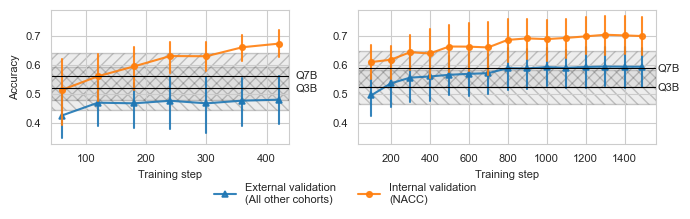

In [16]:
# Create figure with two subplots side by side
# fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)
from matplotlib import gridspec

fig = plt.figure(figsize=(7, 2))  # Set total figure size larger as needed
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1.5])  # Change width_ratios for different sizes
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
axes = [ax1, ax2]
fontsize = 8
linewidth = 1.5
markersize = 4

# Define markers for different groups - update with your actual labels
markers = {
    'External validation\n(All other cohorts)': '^',  # square
    'Internal validation\n(NACC)': 'o'  # circle
}

# Plot 1: SFT
ax1 = axes[0]
for label, group_df in acc_sft.to_pandas().groupby('in_distribution'):
    sns.pointplot(
        data=group_df,
        x='training_steps',
        y='correct',
        native_scale=True,
        errorbar=('ci', 95),
        estimator='mean',
        alpha=0.9,
        linewidth=linewidth,
        marker=markers[label],  # Add marker here
        markersize=markersize,  # Optional: adjust marker size
        ax=ax1,
        label=label
    )

# Add reference lines and shaded regions
ax1.axhline(y=q3b_mean_sft, color='black', linewidth=0.8)
ax1.axhline(y=q7b_mean_sft, color='black', linewidth=0.8)
ax1.axhspan(q3b_low_sft, q3b_high_sft, alpha=0.2, hatch='\\\\\\', edgecolor='black', facecolor='darkgray', zorder=0)
ax1.axhspan(q7b_low_sft, q7b_high_sft, alpha=0.2, hatch='///', edgecolor='black', facecolor='darkgray', zorder=0)
ax1.text(ax1.get_xlim()[1] + 10, q3b_mean_sft, "Q3B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
ax1.text(ax1.get_xlim()[1] + 10, q7b_mean_sft, "Q7B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
ax1.set_ylabel("Accuracy", fontsize=fontsize)
ax1.set_xlabel("Training step", fontsize=fontsize)
# ax1.set_title("SFT", fontsize=fontsize+2, fontweight='bold')
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)

# Plot 2: SCE
ax2 = axes[1]
for label, group_df in acc_sce.to_pandas().groupby('in_distribution'):
    sns.pointplot(
        data=group_df,
        x='training_steps',
        y='correct',
        native_scale=True,
        errorbar=('ci', 95),
        estimator='mean',
        alpha=0.9,
        linewidth=linewidth,
        marker=markers[label],  # Add marker here
        markersize=markersize,  # Optional: adjust marker size
        ax=ax2,
        label=label
    )

# Add reference lines and shaded regions
ax2.axhline(y=q3b_mean_sce, color='black', linewidth=0.8)
ax2.axhline(y=q7b_mean_sce, color='black', linewidth=0.8)
ax2.axhspan(q3b_low_sce, q3b_high_sce, alpha=0.2, hatch='\\\\\\', edgecolor='black', facecolor='darkgray', zorder=0)
ax2.axhspan(q7b_low_sce, q7b_high_sce, alpha=0.2, hatch='///', edgecolor='black', facecolor='darkgray', zorder=0)
ax2.text(ax2.get_xlim()[1] + 10, q3b_mean_sce, "Q3B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
ax2.text(ax2.get_xlim()[1] + 10, q7b_mean_sce, "Q7B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
ax2.set_ylabel("", fontsize=fontsize)  # Remove y-label since sharey=True
ax2.set_xlabel("Training step", fontsize=fontsize)
# ax2.set_title("SCE", fontsize=fontsize+2, fontweight='bold')
ax2.tick_params(axis='x', labelsize=fontsize)
ax2.tick_params(axis='y', labelsize=fontsize)

# Create a single legend at the bottom center
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=fontsize, 
           bbox_to_anchor=(0.5, -0.1), frameon=False)

# Remove individual legends from subplots
ax1.get_legend().remove()
ax2.get_legend().remove()

plt.tight_layout()
# fig.savefig('../figures/fig2_test_perf_over_training.pdf', dpi=200, format="pdf", bbox_inches="tight")
plt.show()

# Ablated models

In [17]:
# Load data for SFT (ignore SCE)
print("Loading NACC-3B data...")
df_nacc_3b = load_data(res_path, include_model="/NACC-3B/")
df_nacc_3b = df_nacc_3b.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())

# Do the same for NACC-3B-SCE
print("Loading NACC-3B-SCE data...")
df_nacc_3b_sce = load_data(res_path, include_model="/NACC-3B-SCE/")
df_nacc_3b_sce = df_nacc_3b_sce.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())

# Do the same for NACC-3B-OS
print("Loading NACC-3B-OS data...")
df_nacc_3b_os = load_data(res_path, include_model="/NACC-3B-OS/")
df_nacc_3b_os = df_nacc_3b_os.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())

# Prepare SCE data with internal/external labels
def get_acc_with_labels(df):
    acc = df.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(
        pl.col('correct').mean()
    ).sort('training_steps')
    acc = acc.with_columns(
        pl.when(pl.col('cohort') == 'nacc_test_updated')
        .then(pl.lit('Internal validation\n(NACC)'))
        .otherwise(pl.lit('External validation\n(All other cohorts)'))
        .alias('in_distribution')
    )
    return acc

acc_nacc_3b = get_acc_with_labels(df_nacc_3b)
acc_nacc_3b_sce = get_acc_with_labels(df_nacc_3b_sce)
acc_nacc_3b_os = get_acc_with_labels(df_nacc_3b_os)

Loading NACC-3B data...


Loading parquet files: 1065it [00:01, 675.37it/s]


Ignored: 957 files
Skipped: set() files
Loading NACC-3B-SCE data...


Loading parquet files: 1065it [00:01, 980.38it/s] 


Ignored: 957 files
Skipped: set() files
Loading NACC-3B-OS data...


Loading parquet files: 1065it [00:01, 750.37it/s]


Ignored: 921 files
Skipped: set() files


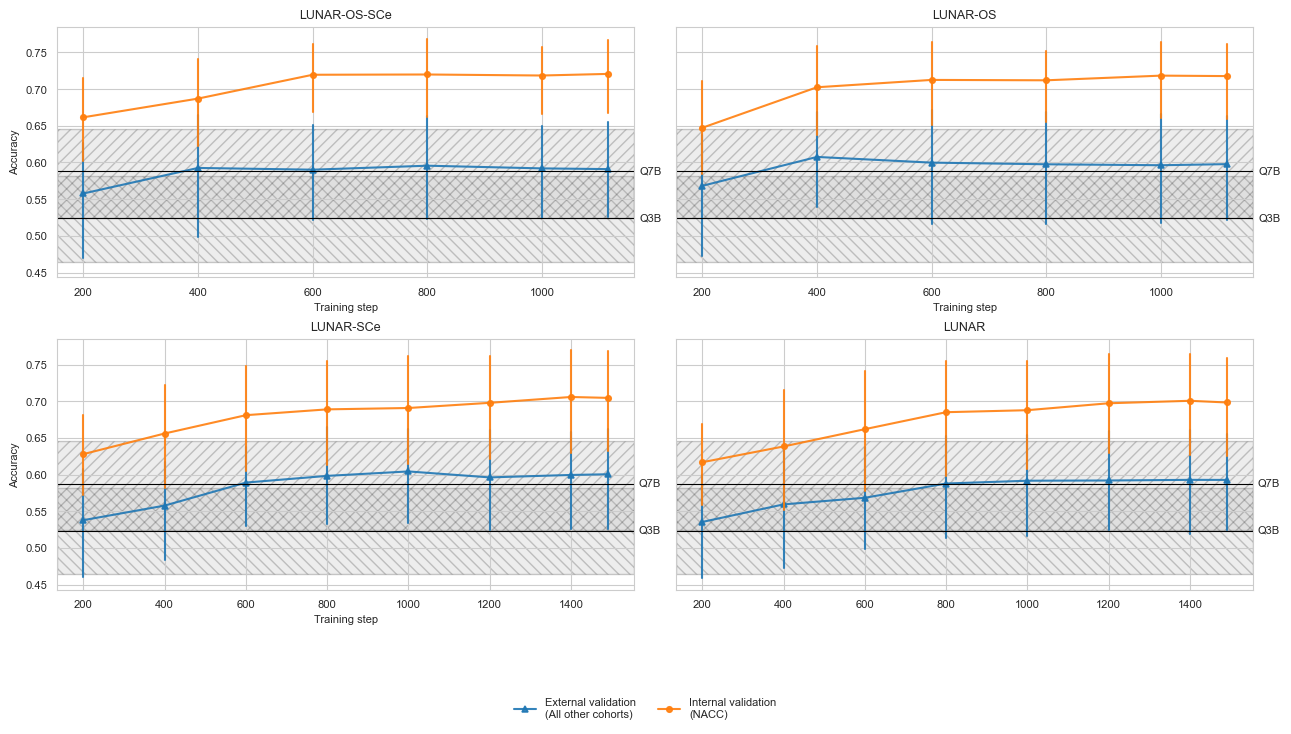

In [18]:
# Create a 2x2 panel plot: acc_nacc_3b, acc_nacc_3b_sce, acc_nacc_3b_os, acc_sce

fontsize = 8
linewidth = 1.5
markersize = 4

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)

panel_titles = [
    "LUNAR-OS-SCe",
    "LUNAR-OS",
    "LUNAR-SCe",
    "LUNAR"
]
# All four plots: group by internal/external validation where possible, use same plotting style everywhere
data_list = [acc_nacc_3b, acc_nacc_3b_sce, acc_nacc_3b_os, acc_sce]

# Define markers for different groups
markers = {
    'External validation\n(All other cohorts)': '^',
    'Internal validation\n(NACC)': 'o'
}

# Flatten axes to handle in a loop easier
axes_flat = axes.flatten()

def select_every_200_and_last(df, step_col="training_steps"):
    """Select every 200th step and ensure the final step is always included."""
    if df.empty:
        return df
    step_vals = df[step_col].unique()
    # Always sort
    step_vals_sorted = np.sort(step_vals)
    # Every 200 (>= 0)
    every_200 = set(step_vals_sorted[step_vals_sorted % 200 == 0])
    # Always add the last step if not included
    last_step = step_vals_sorted[-1]
    every_200.add(last_step)
    # Return only those
    selection = df[df[step_col].isin(list(every_200))].copy()
    # Sort so plots are nice
    selection = selection.sort_values(step_col)
    return selection

for i, ax in enumerate(axes_flat):
    if i < 3:  # The 3 ablation/foundation models
        acc_df = data_list[i].to_pandas()
        for label, group_df in acc_df.groupby('in_distribution'):
            group_df_sub = select_every_200_and_last(group_df, step_col="training_steps")
            sns.pointplot(
                data=group_df_sub,
                x='training_steps',
                y='correct',
                native_scale=True,
                errorbar=('ci', 95),
                estimator='mean',
                alpha=0.9,
                linewidth=linewidth,
                marker=markers[label],
                markersize=markersize,
                ax=ax,
                label=label if i == 0 else None  # Only use label for legend once
            )
        # SCE baselines on each plot, if available
        ax.axhline(y=q3b_mean_sce, color='black', linewidth=0.8)
        ax.axhline(y=q7b_mean_sce, color='black', linewidth=0.8)
        ax.axhspan(q3b_low_sce, q3b_high_sce, alpha=0.2, hatch='\\\\\\', edgecolor='black', facecolor='darkgray', zorder=0)
        ax.axhspan(q7b_low_sce, q7b_high_sce, alpha=0.2, hatch='///', edgecolor='black', facecolor='darkgray', zorder=0)
        ax.text(ax.get_xlim()[1] + 10, q3b_mean_sce, "Q3B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
        ax.text(ax.get_xlim()[1] + 10, q7b_mean_sce, "Q7B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
    elif i == 3:
        # NACC-3B-OS-SCE panel: plot acc_sce with curves for internal/external as in other panels (if acc_sce has those)
        acc_df = data_list[i].to_pandas()
        if 'in_distribution' in acc_df.columns:
            for label, group_df in acc_df.groupby('in_distribution'):
                group_df_sub = select_every_200_and_last(group_df, step_col="training_steps")
                sns.pointplot(
                    data=group_df_sub,
                    x='training_steps',
                    y='correct',
                    native_scale=True,
                    errorbar=('ci', 95),
                    estimator='mean',
                    alpha=0.9,
                    linewidth=linewidth,
                    marker=markers.get(label, 'x'),
                    markersize=markersize,
                    ax=ax,
                    label=label if i == 0 else None
                )
        # SCE baselines
        ax.axhline(y=q3b_mean_sce, color='black', linewidth=0.8)
        ax.axhline(y=q7b_mean_sce, color='black', linewidth=0.8)
        ax.axhspan(q3b_low_sce, q3b_high_sce, alpha=0.2, hatch='\\\\\\', edgecolor='black', facecolor='darkgray', zorder=0)
        ax.axhspan(q7b_low_sce, q7b_high_sce, alpha=0.2, hatch='///', edgecolor='black', facecolor='darkgray', zorder=0)
        ax.text(ax.get_xlim()[1] + 10, q3b_mean_sce, "Q3B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
        ax.text(ax.get_xlim()[1] + 10, q7b_mean_sce, "Q7B", verticalalignment="center", horizontalalignment="left", fontsize=fontsize)
    else:
        pass  # Panel 4 only used for acc_sce as above

    ax.set_title(panel_titles[i], fontsize=fontsize+1)
    if i % 2 == 0:
        ax.set_ylabel("Accuracy", fontsize=fontsize)
    else:
        ax.set_ylabel("")
    ax.set_xlabel("Training step" if i < 3 else "", fontsize=fontsize)
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)

# Custom legend: grab from first axis
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=fontsize, bbox_to_anchor=(0.5, -0.05), frameon=False)

# Remove legends from each axis individually
for ax in axes_flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
# fig.savefig('../figures/fig2_test_perf_ablation_4panel.pdf', dpi=200, format="pdf", bbox_inches="tight")
plt.show()

# Per task plots

In [19]:
# Prepare SCE data with internal/external labels
df_sce_all = df_sce_all.filter(pl.col('benchmark').is_in(['test_mci','test_ftld']).not_())
acc_sce_all = df_sce_all.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(
    pl.col('correct').mean()
).sort('training_steps')

acc_sce_all = acc_sce_all.with_columns(
    pl.when(pl.col('cohort') == 'nacc_test_updated')
    .then(pl.lit('Internal validation\n(NACC)'))
    .otherwise(pl.lit('External validation\n(All other cohorts)'))
    .alias('in_distribution')
)

In [20]:
df_sce_all.head()

ID,ground_truth,prediction,benchmark,cohort,correct,training_steps,model
str,str,str,str,str,i8,i32,str
"""sub-CLB00196""","""A""","""C""","""test_cog""","""brainlat_test""",0,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""C""","""test_cog""","""brainlat_test""",0,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""


In [21]:
# Calculate baseline performances for SCE using df_sce
n_boot = 1000

# Only SCE, per benchmark (not SFT), for both 3B and 7B
base_values_sce = {}  # {benchmark: {"3B": {...}, "7B": {...}}}

for model_size, model_name in [("3B", "Qwen2.5-3B-Instruct"), ("7B", "Qwen2.5-7B-Instruct")]:
    base = (
        df_sce_all.filter(pl.col("model") == model_name)
        .group_by("cohort", "benchmark")
        .agg(pl.col("correct").mean().alias("accuracy"))
    )

    # Get all unique benchmarks
    benchmarks = base["benchmark"].unique().to_list()
    for bench in benchmarks:
        bench_base = base.filter(pl.col("benchmark") == bench)
        bsamples = np.array([
            bench_base.sample(fraction=1, with_replacement=True)
            .select(pl.col("accuracy").mean()).item()
            for _ in range(n_boot)
        ])
        mean = bsamples.mean()
        low = np.quantile(bsamples, 0.025)
        high = np.quantile(bsamples, 0.975)
        if bench not in base_values_sce:
            base_values_sce[bench] = {}
        base_values_sce[bench][model_size] = {
            "mean": mean,
            "low": low,
            "high": high,
            "all_bs": bsamples,
        }

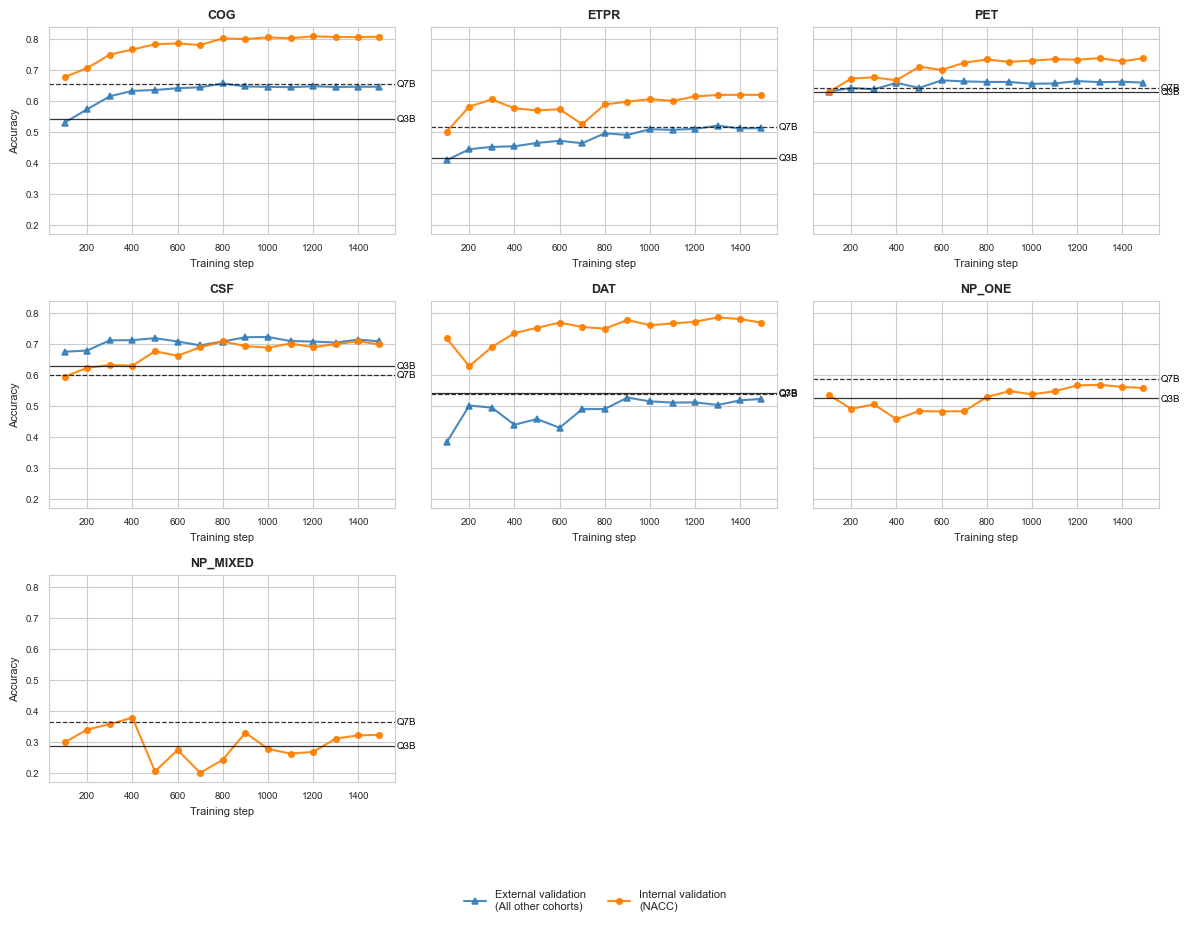

In [24]:
# Plot per-benchmark SCE performance curves with SCE baselines (from base_values_sce)
import math

# Setup figure: one subplot per benchmark
benchmark_label_map = {
    "test_cog": "COG",
    "test_etpr": "ETPR",
    "test_pet": "PET",
    "test_csf": "CSF",
    "test_dat": "DAT",
    "test_np_one": "NP_ONE",
    "test_np_mixed": "NP_MIXED"
}
benchmarks = list(benchmark_label_map.keys())
n_bench = len(benchmarks)
ncols = 3  # You can change this for a different layout
nrows = math.ceil(n_bench / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3), sharey=True
)
fontsize = 8
linewidth = 1.5
markersize = 4

# Markers for distinction
markers = {
    'External validation\n(All other cohorts)': '^',
    'Internal validation\n(NACC)': 'o'
}

# Colors for internal/external validation
colors = {
    'Internal validation\n(NACC)': '#ff7f00',   # blue
    'External validation\n(All other cohorts)': '#377eb8'  # red
}

for idx, benchmark in enumerate(benchmarks):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]

    # Filter for current benchmark
    df_bench = acc_sce_all.filter(pl.col("benchmark") == benchmark).to_pandas()
    base_sce = base_values_sce.get(benchmark, {})

    # Plot SCE accuracy (curve by in_distribution)
    for label, group_df in df_bench.groupby('in_distribution'):
        sns.pointplot(
            data=group_df,
            x='training_steps',
            y='correct',
            native_scale=True,
            # errorbar=('ci', 95),
            # estimator='mean',
            errorbar=None,  # Turn off error bars
            alpha=0.9,
            linewidth=linewidth,
            marker=markers[label],
            markersize=markersize,
            color=colors[label],
            ax=ax,
            label=label if idx == 0 else None,  # Only show label once in legend
        )
    
    # Reference lines/shaded regions for SCE baselines 3B and 7B if available
    for size in ["3B", "7B"]:
        cur = base_sce.get(size)
        if cur is not None:
            ax.axhline(y=cur["mean"], color='black', linewidth=0.9, linestyle='-' if size == "3B" else '--', alpha=0.8)
            hatch_styles = {'3B': '\\\\\\', '7B': '///'}
            # ax.axhspan(
            #     cur["low"], cur["high"], alpha=0.18,
            #     facecolor='darkgray',
            #     edgecolor='black',
            #     hatch=hatch_styles[size],
            #     zorder=0)
            ax.text(
                ax.get_xlim()[1] + 10, cur["mean"], f"Q{size}",
                va="center", ha="left", fontsize=fontsize-1, color='black'
            )

    # Use benchmark_label_map for the title
    ax.set_title(benchmark_label_map.get(benchmark, benchmark), fontsize=fontsize+1, fontweight='bold')
    ax.set_xlabel("Training step", fontsize=fontsize)
    if col == 0:
        ax.set_ylabel("Accuracy", fontsize=fontsize)
    else:
        ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=fontsize-1)
    ax.tick_params(axis='y', labelsize=fontsize-1)

# Clean up empty axes (if any)
total_axes = nrows * ncols
for idx in range(len(benchmarks), total_axes):
    ax = axes[idx // ncols, idx % ncols] if nrows > 1 else axes[idx % ncols]
    ax.axis('off')

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels() if nrows > 1 else axes[0].get_legend_handles_labels()

# Remove legends from individual panels
axs = axes.flatten() if nrows > 1 else axes
for ax in axs:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
        
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=fontsize,
           bbox_to_anchor=(0.5, -0.03), frameon=False)

plt.tight_layout(rect=[0, 0.07, 1, 1])
# fig.savefig('../figures/fig2a_sce_per_benchmark_over_training.pdf', dpi=200, format="pdf", bbox_inches="tight")
plt.show()